# HANDS-ON SESSION 8
## Python + Google Colab + BigQuery — TheLook Ecommerce Analysis

**Dataset:** `bigquery-public-data.thelook_ecommerce`  
**Level:** Basic / Pemula  
**Lanjutan dari:** Sesi 7 — Data Cleaning & EDA

### Alur Project
**BigQuery → Pandas → Cleaning → EDA → Analysis → Insight**

Pada sesi ini peserta melanjutkan dataset bersih dari Sesi 7 dan membuat analisis Python yang lebih terarah.

> Fokus tetap basic: filtering, grouping, aggregation, sorting, persentase, trend, dan visualisasi sederhana. Tidak menggunakan machine learning.


## 1. Setup Google Colab & BigQuery

In [2]:
!pip -q install google-cloud-bigquery db-dtypes


In [3]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

PROJECT_ID = "latihan-pertama-505507"
client = bigquery.Client(project=PROJECT_ID)

print("Connected to:", PROJECT_ID)


Connected to: latihan-pertama-505507


## 2. Cek Tabel TheLook Ecommerce

In [4]:
query = '''
SELECT
  table_name
FROM `bigquery-public-data.thelook_ecommerce.INFORMATION_SCHEMA.TABLES`
ORDER BY table_name
'''

client.query(query).to_dataframe()


,table_name
0,distribution_centers
1,events
2,inventory_items
3,order_items
4,orders
5,products
6,users


# BAGIAN A — AMBIL DATA DARI BIGQUERY

## 3. Ambil Orders untuk Analisis

Kita mengambil data dari tabel `orders`.


In [5]:
query = '''
SELECT
  order_id,
  user_id,
  status,
  created_at
FROM `bigquery-public-data.thelook_ecommerce.orders`
'''

df = client.query(query).to_dataframe()

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 125345
Columns: 4


## 4. Persiapan Tipe Data

In [6]:
import pandas as pd

df["created_at"] = pd.to_datetime(
    df["created_at"],
    errors="coerce"
)

df["order_date"] = df["created_at"].dt.date
df["month"] = df["created_at"].dt.to_period("M").astype(str)

df.head()


/tmp/ipykernel_1412/433568497.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["created_at"].dt.to_period("M").astype(str)


,order_id,user_id,status,created_at,order_date,month
0,34,25,Cancelled,2026-08-17 15:05:19+00:00,2026-08-17,2026-08
1,38,28,Cancelled,2026-05-03 01:53:14+00:00,2026-05-03,2026-05
2,90,69,Cancelled,2026-06-24 01:22:38+00:00,2026-06-24,2026-06
3,110,85,Cancelled,2023-06-07 03:28:53+00:00,2023-06-07,2023-06
4,113,88,Cancelled,2021-04-18 03:36:56+00:00,2021-04-18,2021-04


# BAGIAN B — ANALISIS STATUS

## 5. Jumlah Order per Status

In [7]:
status_summary = (
    df["status"]
      .value_counts()
      .reset_index()
)

status_summary.columns = [
    "status",
    "total_orders"
]

status_summary


,status,total_orders
0,Shipped,37899
1,Complete,31196
2,Processing,24916
3,Cancelled,18775
4,Returned,12559


## 6. Persentase Order per Status

In [8]:
status_summary["percentage"] = (
    status_summary["total_orders"]
    / status_summary["total_orders"].sum()
    * 100
).round(2)

status_summary


,status,total_orders,percentage
0,Shipped,37899,30.24
1,Complete,31196,24.89
2,Processing,24916,19.88
3,Cancelled,18775,14.98
4,Returned,12559,10.02


## 7. Visualisasi Status

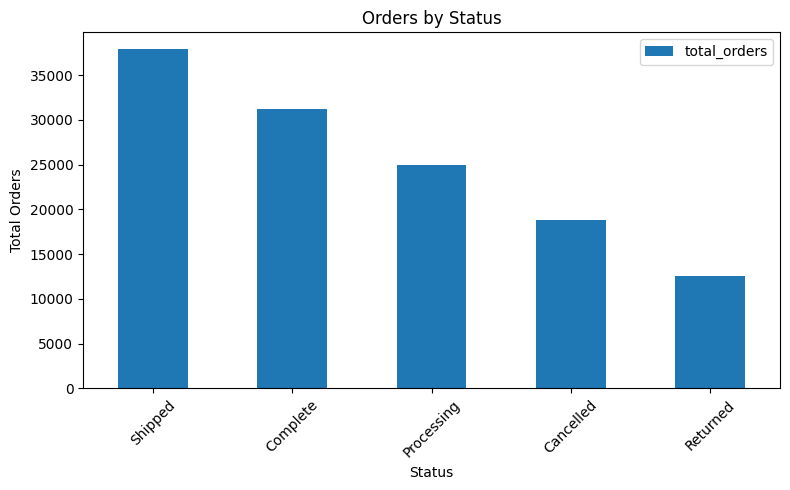

In [9]:
import matplotlib.pyplot as plt

status_summary.plot(
    x="status",
    y="total_orders",
    kind="bar",
    figsize=(8,5)
)

plt.title("Orders by Status")
plt.xlabel("Status")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# BAGIAN C — ANALISIS WAKTU

## 8. Orders per Month

In [10]:
monthly_orders = (
    df.groupby("month")
      .size()
      .reset_index(name="total_orders")
)

monthly_orders


,month,total_orders
0,2019-01,5
1,2019-02,13
2,2019-03,34
3,2019-04,49
4,2019-05,66
...,...,...
88,2026-05,4312
89,2026-06,4538
90,2026-07,5293
91,2026-08,6236


## 9. Bulan dengan Order Tertinggi

In [11]:
top_month = (
    monthly_orders
    .sort_values("total_orders", ascending=False)
    .head(1)
)

top_month


,month,total_orders
92,2026-09,6246


## 10. Visualisasi Trend Bulanan

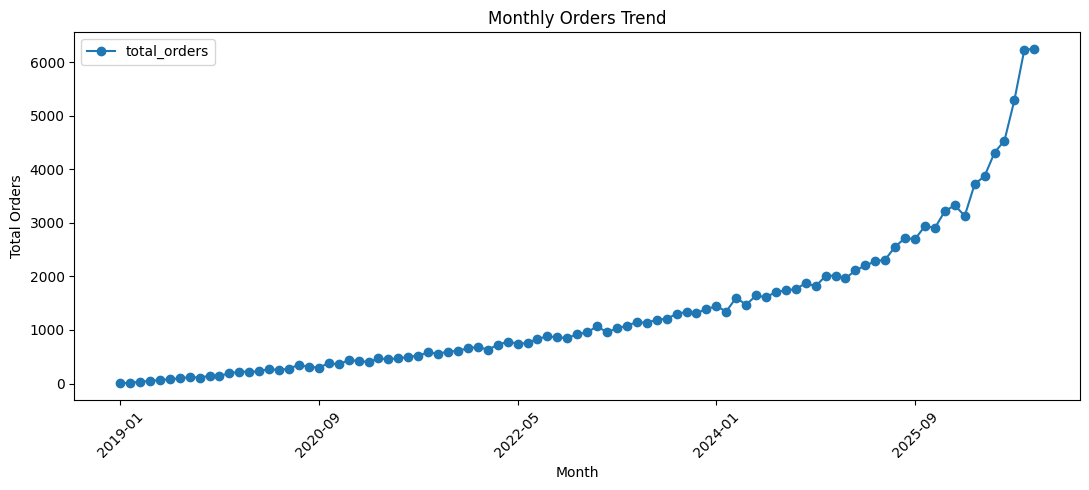

In [12]:
monthly_orders.plot(
    x="month",
    y="total_orders",
    kind="line",
    marker="o",
    figsize=(11,5)
)

plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 11. Orders per Hari

In [13]:
daily_orders = (
    df.groupby("order_date")
      .size()
      .reset_index(name="total_orders")
)

daily_orders.head()


,order_date,total_orders
0,2019-01-11,1
1,2019-01-12,1
2,2019-01-17,1
3,2019-01-18,1
4,2019-01-30,1


## 12. Top 10 Hari dengan Order Terbanyak

In [14]:
top_days = (
    daily_orders
    .sort_values("total_orders", ascending=False)
    .head(10)
)

top_days


,order_date,total_orders
2736,2026-09-11,1757
2735,2026-09-10,1066
2734,2026-09-09,782
2733,2026-09-08,627
2732,2026-09-07,427
2728,2026-09-03,295
2731,2026-09-06,286
2722,2026-08-28,252
2729,2026-09-04,245
2720,2026-08-26,243


# BAGIAN D — ANALISIS COMPLETE

## 13. Complete Orders

In [15]:
complete_df = df[
    df["status"] == "Complete"
].copy()

print("Complete Orders:", len(complete_df))


Complete Orders: 31196


In [16]:
#catatan: complete_df adalah dataframe dimana pada coding ini mengambil semua dataframe, bisa diketahui karena df.["status"]
#kemudian df["status"] =="Complete" memfilter, hanya mengambil status dengan orderan Complete
#ini artinya semua dataframe dari df diambil dan hanya dengan status Complete.
#kemudian di copy agar dataframe asli tidak hilang

## 14. Complete Rate

In [17]:
#catatan, pada perhitungan complete_rate tidak perlu dataframe karena complete_orders dan total_orders adalah variabel
#v berbeda dengan kasus hands on 7 dimana ada dua kolom dalam satu dataframe, jika tidak diberi dataframe maka python
#akan kebingungan menentukan kolom mana yang akan dipakai

total_orders = len(df)
complete_orders = len(complete_df)

complete_rate = round(
    complete_orders / total_orders * 100,
    2
)

print("Total Orders   :", total_orders)
print("Complete Orders:", complete_orders)
print("Complete Rate  :", complete_rate, "%")


Total Orders   : 125345
Complete Orders: 31196
Complete Rate  : 24.89 %


In [18]:
complete_df.columns

Index(['order_id', 'user_id', 'status', 'created_at', 'order_date', 'month'], dtype='object')

## 15. Complete Orders per Month

In [19]:
#membuat kolom bulan atau menimpa jg bisa dengan kolom created_at dari dataframe complete_df yang pernah dibuat
#kemudian maksud dari baris pertama adalah pada dataframe complete_df kolom month
#isinya mau diganti dengan created_at dengan mengkhususkan isinya bulan dan tahun dgn cara dt.to_period["M"]
complete_df["month"] = (
    complete_df["created_at"]
    .dt.to_period("M")
    .astype(str)
)

complete_monthly = (
    complete_df
    .groupby("month")
    .size()
    .reset_index(name="complete_orders")
)

complete_monthly


/tmp/ipykernel_1412/4026906006.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


,month,complete_orders
0,2019-01,1
1,2019-02,7
2,2019-03,10
3,2019-04,11
4,2019-05,11
...,...,...
88,2026-05,1068
89,2026-06,1146
90,2026-07,1352
91,2026-08,1614


## 16. All Orders vs Complete Orders

In [20]:
comparison = monthly_orders.merge(
    complete_monthly,
    on="month",
    how="left"
).fillna(0)

comparison["complete_orders"] = (
    comparison["complete_orders"].astype(int)
)

comparison.head()


,month,total_orders,complete_orders
0,2019-01,5,1
1,2019-02,13,7
2,2019-03,34,10
3,2019-04,49,11
4,2019-05,66,11


## 17. Visualisasi All vs Complete

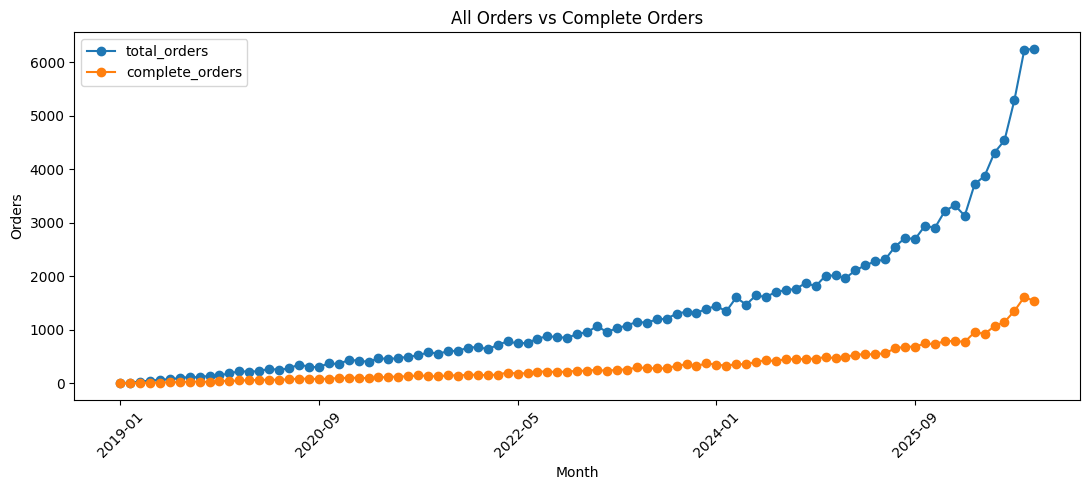

In [21]:
comparison.plot(
    x="month",
    y=["total_orders", "complete_orders"],
    kind="line",
    marker="o",
    figsize=(11,5)
)

plt.title("All Orders vs Complete Orders")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [22]:
comparison.columns

Index(['month', 'total_orders', 'complete_orders'], dtype='object')

# BAGIAN E — ANALISIS USER

## 18. Ambil Data Users dari BigQuery

Untuk basic analysis, kita gunakan tabel `users` secara terpisah.


In [23]:
query_users = '''
SELECT
  id AS user_id,
  first_name,
  last_name,
  gender,
  age,
  country
FROM `bigquery-public-data.thelook_ecommerce.users`
'''

users = client.query(query_users).to_dataframe()

users.head()


,user_id,first_name,last_name,gender,age,country
0,73326,Jennifer,Rodriguez,F,12,Brasil
1,4231,Brenda,Nunez,F,12,Brasil
2,95132,Phillip,Carlson,M,12,Brasil
3,2768,Laura,Jones,F,12,United States
4,32898,Samantha,Jimenez,F,12,Brasil


## 19. Distribusi Gender User

In [24]:
gender_summary = (
    users["gender"]
    .value_counts()
    .reset_index()
)

gender_summary.columns = [
    "gender",
    "total_users"
]

gender_summary


,gender,total_users
0,F,50090
1,M,49910


In [25]:
gender_summary.columns

Index(['gender', 'total_users'], dtype='object')

## 20. Rata-rata Usia User

In [26]:
average_age = round(
    users["age"].mean(),
    2
)

print("Average Age:", average_age)


Average Age: 40.94


## 21. Top 10 Country berdasarkan Jumlah User

In [27]:
country_summary = (
    users["country"]
    .value_counts()
    .reset_index()
)

country_summary.columns = [
    "country",
    "total_users"
]

top_country = country_summary.head(10)

top_country


,country,total_users
0,China,33732
1,United States,22746
2,Brasil,14468
3,South Korea,5271
4,France,4711
5,United Kingdom,4581
6,Germany,4270
7,Spain,4050
8,Japan,2517
9,Australia,2121


## 22. Visualisasi Top Country

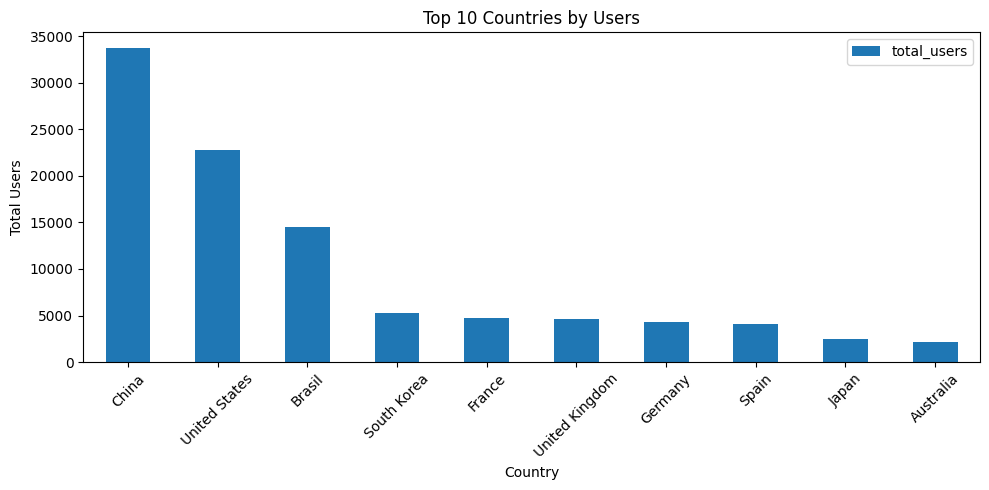

In [28]:
top_country.plot(
    x="country",
    y="total_users",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries by Users")
plt.xlabel("Country")
plt.ylabel("Total Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# BAGIAN F — BUSINESS QUESTIONS

## 23. Jawab Pertanyaan Berikut

Gunakan hasil analisis untuk menjawab:

1. Status order apa yang paling banyak?
2. Berapa Complete Rate?
3. Bulan mana dengan order terbanyak?
4. Hari mana dengan order terbanyak?
5. Berapa rata-rata usia user?
6. Country mana dengan jumlah user terbanyak?
7. Apakah trend Complete Orders mengikuti trend seluruh Orders?


In [29]:
print("===== KEY METRICS =====")
print("Total Orders   :", total_orders)
print("Complete Orders:", complete_orders)
print("Complete Rate  :", complete_rate, "%")
print("Average Age    :", average_age)

print("\nTop Month:")
display(top_month)

print("\nTop 10 Countries:")
display(top_country)

print("\nStatus Summary:")
display(status_summary)

#display() adalah fungsi python untuk menampilkan dataframe lebih rapi dari print
# (bukan series)

===== KEY METRICS =====
Total Orders   : 125345
Complete Orders: 31196
Complete Rate  : 24.89 %
Average Age    : 40.94

Top Month:


,month,total_orders
92,2026-09,6246



Top 10 Countries:


,country,total_users
0,China,33732
1,United States,22746
2,Brasil,14468
3,South Korea,5271
4,France,4711
5,United Kingdom,4581
6,Germany,4270
7,Spain,4050
8,Japan,2517
9,Australia,2121



Status Summary:


,status,total_orders,percentage
0,Shipped,37899,30.24
1,Complete,31196,24.89
2,Processing,24916,19.88
3,Cancelled,18775,14.98
4,Returned,12559,10.02


# BAGIAN G — MINI PROJECT

## 24. Buat Ringkasan Analisis

Buat sebuah tabel ringkasan yang berisi KPI utama.


In [30]:
#total ada di nomor 14, ada variabel total_order =df(len)

kpi = pd.DataFrame({
    "metric": [
        "Total Orders",
        "Complete Orders",
        "Complete Rate",
        "Average User Age"
    ],
    "value": [
        total_orders,
        complete_orders,
        complete_rate,
        average_age
    ]
})

kpi


,metric,value
0,Total Orders,125345.00
1,Complete Orders,31196.00
2,Complete Rate,24.89
3,Average User Age,40.94


## 25. Tulis Minimal 3 Insight

Gunakan pola:
- **Insight 1:** berdasarkan status.
- **Insight 2:** berdasarkan trend waktu.
- **Insight 3:** berdasarkan user / country.

Contoh format:
> “Status X memiliki jumlah order paling tinggi dibandingkan status lainnya.”

Jangan membuat klaim sebab-akibat yang tidak didukung data.


In [31]:
# TULIS INSIGHT ANDA DI SINI

insight_1 = "Status Shipped memili total_order yang paling tinggi dibandingkan dengan status lainnya. "
insight_2 = "Tahun 2025 antara bulan 8 dan 9 adalah total order dan complete order terbanyak dari bulan dan tahun lainnya"
insight_3 = "Negara China memiliki total order terbanyak dengan nilai 33895 dari negara lainnya"

print("Insight 1:", insight_1)
print("Insight 2:", insight_2)
print("Insight 3:", insight_3)


Insight 1: Status Shipped memili total_order yang paling tinggi dibandingkan dengan status lainnya. 
Insight 2: Tahun 2025 antara bulan 8 dan 9 adalah total order dan complete order terbanyak dari bulan dan tahun lainnya
Insight 3: Negara China memiliki total order terbanyak dengan nilai 33895 dari negara lainnya


# BAGIAN H — EXPORT HASIL

## 26. Simpan Hasil Analisis

File summary ini dapat digunakan kembali pada sesi berikutnya.


In [32]:
# kpi.to_csv(
#     "session8_kpi.csv",
#     index=False
# )

# status_summary.to_csv(
#     "session8_status_summary.csv",
#     index=False
# )

# monthly_orders.to_csv(
#     "session8_monthly_orders.csv",
#     index=False
# )

# top_country.to_csv(
#     "session8_top_country.csv",
#     index=False
# )

# print("File summary berhasil dibuat.")


In [33]:
# from google.colab import files

# for filename in [
#     "session8_kpi.csv",
#     "session8_status_summary.csv",
#     "session8_monthly_orders.csv",
#     "session8_top_country.csv"
# ]:
#     files.download(filename)


# OUTPUT SESI 8

Peserta menghasilkan:

- KPI utama.
- Status analysis.
- Percentage analysis.
- Monthly trend.
- Daily order analysis.
- Complete Rate.
- User analysis.
- Top Country.
- Minimal 3 insight.
- File summary CSV.

### Handoff
**Sesi 8 — Python Analysis**
↓
**Sesi 9 — Final Python Analysis / Preparation**
↓
**Power BI**


# LATIHAN MANDIRI

### Soal 1
Buat persentase user berdasarkan gender.

### Soal 2
Cari 5 bulan dengan jumlah Complete Orders tertinggi.

### Soal 3
Buat chart baru untuk status order.

### Soal 4
Buat satu KPI tambahan.

### Soal 5
Tuliskan 3 insight yang berbeda dari contoh.

**Tools yang boleh digunakan:** Pandas + Matplotlib.


In [34]:
#Soal 1. Buatlah presentase gender berdasarkan user

gender_summary = (
    users["gender"]
    .value_counts()
    .reset_index(name= "gender_orders")
)

gender_rate = round(
     gender_summary["gender_orders"] / gender_summary ["gender_orders"].sum() * 100,
    2
)

gender_summary["gender_rate"] = gender_rate


gender_summary

,gender,gender_orders,gender_rate
0,F,50090,50.09
1,M,49910,49.91


In [35]:
#2. Cari 5 bulan dengan complete order tertinggi

complete_df = df[
    df["status"] == "Complete"
].copy()

complete_df["month"] = (
    complete_df["created_at"]
    .dt.to_period("M")
    .astype(str)
)

complete_monthly = (
    complete_df
    .groupby("month")
    .size()
    .reset_index(name="complete_orders")
    .sort_values("complete_orders", ascending=False)
)

complete_monthly.head(5)



/tmp/ipykernel_1412/492915561.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


,month,complete_orders
91,2026-08,1614
92,2026-09,1537
90,2026-07,1352
89,2026-06,1146
88,2026-05,1068


In [36]:
complete_monthly.columns

Index(['month', 'complete_orders'], dtype='object')

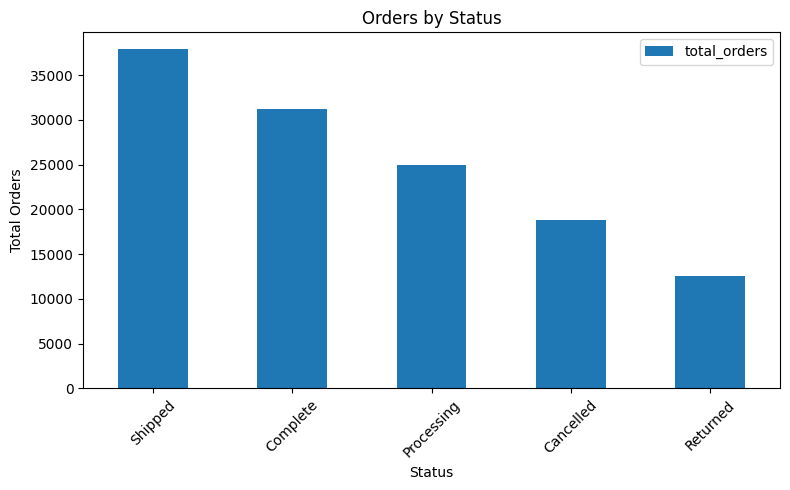

In [37]:
#no 3. buat chart baru dengan status order

import matplotlib.pyplot as plt

status_summary.plot(
    x="status",
    y="total_orders",
    kind="bar",
    figsize=(8,5)
)

plt.title("Orders by Status")
plt.xlabel("Status")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [38]:
# NO 4. Buat satu KPI tambahan
# membuat berapa persen barang yang dikembalikan

returned_orders = (df["status"] == "Returned").sum()

return_rate = round(
    returned_orders / total_orders * 100,
    2
)

print(f"Return Rate: {return_rate}%")

Return Rate: 10.02%


In [39]:
#memasukkanya kembali ke dataframe
kpi.loc[len(kpi)] = ["Return Rate %", return_rate]

kpi

,metric,value
0,Total Orders,125345.00
1,Complete Orders,31196.00
2,Complete Rate,24.89
3,Average User Age,40.94
4,Return Rate %,10.02


In [40]:
# #5. Tuliskan 3 insight yang berbeda dari contoh

# 1. Pengguna TheLook Ecommers rata-rata di usia 41 tahun yang didominasi oleh wanita (Female) sebanyak 50090 daripada laki-laki (Male)
#    sebanyak 49910.
# 2. Pengembalian barang (return) berada pada 10,2 persen, terendah dari seluruh status yang ada.
# 3. Total order memiliki value lebih besar dibandingkan Complete Orders.


SyntaxError: invalid syntax (842142860.py, line 3)